$$P = G\left\{ k_B T_{N} + \frac{k_B T}{2}\left[\left( \frac{eV_{audio}(t) + hf_{RF}}{2k_B T}\right)\coth{\left( \frac{eV_{audio}(t) + hf_{RF}}{2k_B T}\right)} + \left( \frac{eV_{audio}(t) - hf_{RF}}{2k_B T}\right)\coth{\left( \frac{eV_{audio}(t) - hf_{RF}}{2k_B T}\right)}\right]\right\}$$


$$P = G\left\{k_B T_{N} + \frac{k_B T}{2}\left[\left( \frac{e V_{peak}\sin{(2\pi f_{audio} t  + \psi_{audio})} + hf_{RF}}{2k_B T}\right)\coth{\left( \frac{eV_{peak}\sin{(2\pi f_{audio} t  + \psi_{audio})} + hf_{RF}}{2k_B T}\right)} + \left( \frac{eV_{peak}\sin{(2\pi f_{audio} t  + \psi_{audio})} - hf_{RF}}{2k_B T}\right)\coth{\left( \frac{eV_{peak}\sin{(2\pi f_{audio} t  + \psi_{audio})} - hf_{RF}}{2k_B T}\right)}\right]\right\}$$

$$P = G\left\{k_B T_{N} + \frac{k_B T}{2}\left[\textbf{xcothx}{\left( \frac{eV_{peak}\sin{(2\pi f_{audio} t  + \psi_{audio})} + hf_{RF}}{2k_B T}\right)} + \textbf{xcothx}{\left( \frac{eV_{peak}\sin{(2\pi f_{audio} t  + \psi_{audio})} - hf_{RF}}{2k_B T}\right)}\right]\right\}$$

$$P(t,\phi,\eta,\theta,\psi,\theta_N,G) = G\left\{\theta_N + \frac{\theta}{2}\left[\textbf{xcothx}{\left( \frac{\eta\sin{(2\pi f_{audio} t  + \psi_{audio})} + \phi}{2\theta}\right)} + \textbf{xcothx}{\left( \frac{\eta\sin{(2\pi f_{audio} t  + \psi_{audio})} - \phi}{2\theta}\right)}\right]\right\}$$

$k_B T$ is in units of pixels. P is in units of pixels. G is dimensionless linear gain. $eV_{audio}$ is in units of pixels. hf is in units of pixels.  In reduced form, $\theta = k_B T$, $\phi = hf_{RF}$, and $\eta = eV^{audio}_{peak}$, all measured in units of pixels with the same conversion between pixels and yoctojoules.



In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import time

In [2]:
def xcothx1(x):
    if x == 0:
        return 1
    else:
        return x/np.tanh(x)
xcothx = np.frompyfunc(xcothx1, 1, 1)#https://numpy.org/doc/stable/reference/generated/numpy.frompyfunc.html#numpy.frompyfunc


In [42]:
def xcothx2(x):
    return x/np.tanh(x)

In [43]:
def p_of_t(t,photon_energy,thermal_energy,peak_audio_energy,audio_period,audio_phase,noise_energy,gain):
    term1 = xcothx((peak_audio_energy * np.sin((2 * np.pi * t / audio_period) + (np.pi * audio_phase / 180)) + photon_energy) / (2 * thermal_energy)).astype(np.float64)
    term2 = xcothx((peak_audio_energy * np.sin((2 * np.pi * t / audio_period) + (np.pi * audio_phase / 180)) - photon_energy) / (2 * thermal_energy)).astype(np.float64)
    return gain * (noise_energy + 0.5 * thermal_energy * (term1 + term2))

(0.0, 1000.0)

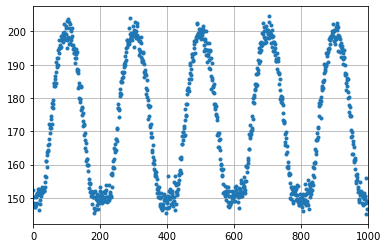

In [44]:
photon_energy = 100
thermal_energy = 10
peak_audio_energy = 200
audio_period = 400
audio_phase = 0
noise_energy = 100
sigma = 2
gain = 1
timewave = np.arange(0,1000,1.0)
noisewave = p_of_t(timewave,photon_energy,thermal_energy,peak_audio_energy,audio_period,audio_phase,noise_energy,gain) + np.random.normal(0, sigma, len(timewave))
noisewave2 = noisewave.astype(np.float64)
plt.plot(timewave,noisewave2,'.')
plt.grid()
plt.xlim(0,len(timewave))

In [22]:
def foo(x,T):
    return T*xcothx(x/T)

foobar = np.frompyfunc(foo, 1, 1)#https://numpy.org/doc/stable/reference/generated/numpy.frompyfunc.html#numpy.frompyfunc


In [45]:
popt, pcov = curve_fit(p_of_t, timewave, noisewave2)


In [46]:
popt

array([-2.62285316e+01,  2.96282103e+00,  6.97618712e+01,  9.96789427e-01,
        8.59789009e+02,  2.67264635e+02,  5.93142116e-01])

In [26]:
def sin2f(t,psi,offset,peak,period):
    return offset + peak*np.sin((np.pi*psi/180) + (4*np.pi*t/period))


In [37]:
popt, pcov = curve_fit(foobar, timewave, noisewavefixed)


ValueError: callable <ufunc 'foo (vectorized)'> is not supported by signature

In [35]:
popt

array([ 8.75921971e+01, -2.65046741e+03,  2.82369514e+03,  9.99993497e-01])

In [38]:
0.00001/np.tanh(0.00001)

1.0000000000333333

In [56]:
timewave

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
        77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
        88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
        99., 100., 101., 102., 103., 104., 105., 106., 107., 108., 109.,
       110., 111., 112., 113., 114., 115., 116., 117., 118., 119., 120.,
       121., 122., 123., 124., 125., 126., 127., 128., 129., 130., 131.,
       132., 133., 134., 135., 136., 137., 138., 139., 140., 141., 142.,
       143., 144., 145., 146., 147., 148., 149., 15

TypeError: 'numpy.ndarray' object is not callable

In [31]:
noisewavefixed = noisewave.astype(np.float64)

In [40]:
for number in noisewave:
    print(type(number))

<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.fl